# Footballer Face-Only Segmentation Pipeline

This notebook implements an annotation-free preprocessing pipeline that extracts only footballers' faces for CycleGAN preparation.

- Input: all images under `dataset/`
- Segmentation: pretrained inference only
- Output: standardized `256x256` face-only exports
- Includes: input validation, robust error handling, and unit tests

## 1) Set Up Workspace and Imports
Import dependencies, enforce reproducibility defaults, and print runtime information.

In [1]:
import os
import sys
import json
import random
import platform
import traceback
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple, Any

import numpy as np
from PIL import Image

try:
    import cv2
except Exception as exc:
    raise RuntimeError("OpenCV is required. Install with: pip install opencv-python") from exc

try:
    import matplotlib.pyplot as plt
except Exception as exc:
    raise RuntimeError("Matplotlib is required. Install with: pip install matplotlib") from exc

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Python:", sys.version)
print("Platform:", platform.platform())
print("OpenCV:", cv2.__version__)
print("NumPy:", np.__version__)

Python: 3.13.12 (tags/v3.13.12:1cbe481, Feb  3 2026, 18:22:25) [MSC v.1944 64 bit (AMD64)]
Platform: Windows-10-10.0.19045-SP0
OpenCV: 4.13.0
NumPy: 2.4.3


## 2) Define Project Structure and Configuration
Centralized configuration for paths, thresholds, face visibility filtering, and export settings.

In [2]:
@dataclass
class PipelineConfig:
    dataset_dir: Path = Path("dataset")
    output_dir: Path = Path("outputs_faces")
    image_size: int = 256
    supported_exts: Tuple[str, ...] = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

    person_conf_threshold: float = 0.25
    max_images: Optional[int] = None
    random_sample: bool = False

    min_face_component_area: int = 120
    face_crop_padding_ratio: float = 0.18

    # Enforce a consistent crop convention for CycleGAN domains.
    center_face_exports: bool = True
    target_face_fill_ratio: float = 0.92
    target_face_center_y_ratio: float = 0.5

    # Visibility quality gates to skip tiny / low-information face candidates.
    min_face_bbox_side: int = 30
    min_face_bbox_area: int = 900
    min_face_area_ratio: float = 0.00055
    min_face_fill_ratio: float = 0.12
    min_face_intensity_std: float = 12.0

    # Second-stage feature verification (facial landmarks / face detector).
    use_face_feature_verifier: bool = True
    min_verified_face_side: int = 30
    min_face_landmarks: int = 80

    save_face_mask: bool = False
    background_color: Tuple[int, int, int] = (0, 0, 0)


def validate_config(config: PipelineConfig) -> None:
    if not config.dataset_dir.exists() or not config.dataset_dir.is_dir():
        raise ValueError(f"Dataset directory not found: {config.dataset_dir}")
    if config.image_size <= 0:
        raise ValueError("image_size must be > 0")
    if not (0.0 <= config.person_conf_threshold <= 1.0):
        raise ValueError("person_conf_threshold must be in [0, 1]")
    if config.min_face_component_area <= 0:
        raise ValueError("min_face_component_area must be > 0")
    if not (0.0 <= config.face_crop_padding_ratio <= 1.0):
        raise ValueError("face_crop_padding_ratio must be in [0, 1]")
    if not (0.2 <= config.target_face_fill_ratio <= 0.98):
        raise ValueError("target_face_fill_ratio must be in [0.2, 0.98]")
    if not (0.25 <= config.target_face_center_y_ratio <= 0.75):
        raise ValueError("target_face_center_y_ratio must be in [0.25, 0.75]")
    if config.min_face_bbox_side <= 0:
        raise ValueError("min_face_bbox_side must be > 0")
    if config.min_face_bbox_area <= 0:
        raise ValueError("min_face_bbox_area must be > 0")
    if not (0.0 < config.min_face_area_ratio <= 1.0):
        raise ValueError("min_face_area_ratio must be in (0, 1]")
    if not (0.0 <= config.min_face_fill_ratio <= 1.0):
        raise ValueError("min_face_fill_ratio must be in [0, 1]")
    if config.min_face_intensity_std < 0.0:
        raise ValueError("min_face_intensity_std must be >= 0")
    if config.min_verified_face_side <= 0:
        raise ValueError("min_verified_face_side must be > 0")
    if config.min_face_landmarks <= 0:
        raise ValueError("min_face_landmarks must be > 0")


config = PipelineConfig()
validate_config(config)
print(config)

PipelineConfig(dataset_dir=WindowsPath('dataset'), output_dir=WindowsPath('outputs_faces'), image_size=256, supported_exts=('.jpg', '.jpeg', '.png', '.bmp', '.webp'), person_conf_threshold=0.25, max_images=None, random_sample=False, min_face_component_area=120, face_crop_padding_ratio=0.18, center_face_exports=True, target_face_fill_ratio=0.92, target_face_center_y_ratio=0.5, min_face_bbox_side=30, min_face_bbox_area=900, min_face_area_ratio=0.00055, min_face_fill_ratio=0.12, min_face_intensity_std=12.0, use_face_feature_verifier=True, min_verified_face_side=30, min_face_landmarks=80, save_face_mask=False, background_color=(0, 0, 0))


## 3) Implement Core Functions
Face-only implementation with modular functions and type hints.

In [3]:
def list_images(dataset_dir: Path, exts: Tuple[str, ...]) -> List[Path]:
    """Return all image files in dataset_dir recursively, sorted for deterministic processing."""
    return sorted([p for p in dataset_dir.rglob("*") if p.suffix.lower() in exts and p.is_file()])


def ensure_dirs(output_dir: Path, save_face_mask: bool = False) -> Dict[str, Path]:
    """Create and return export directories."""
    paths = {
        "faces": output_dir / "faces"
    }
    if save_face_mask:
        paths["face_mask"] = output_dir / "face_mask"
    for p in paths.values():
        p.mkdir(parents=True, exist_ok=True)
    return paths


def read_rgb(path: Path) -> np.ndarray:
    """Read image as RGB uint8 array."""
    with Image.open(path) as img:
        return np.array(img.convert("RGB"), dtype=np.uint8)


def resize_with_padding_rgb(img_rgb: np.ndarray, size: int, bg: Tuple[int, int, int]) -> np.ndarray:
    """Resize to square with preserved aspect ratio and padding."""
    h, w = img_rgb.shape[:2]
    if h == 0 or w == 0:
        raise ValueError("Invalid image with zero dimension")
    scale = min(size / w, size / h)
    nw, nh = int(round(w * scale)), int(round(h * scale))
    resized = cv2.resize(img_rgb, (nw, nh), interpolation=cv2.INTER_AREA)
    canvas = np.full((size, size, 3), np.array(bg, dtype=np.uint8), dtype=np.uint8)
    y0 = (size - nh) // 2
    x0 = (size - nw) // 2
    canvas[y0:y0 + nh, x0:x0 + nw] = resized
    return canvas


def resize_with_padding_mask(mask: np.ndarray, size: int) -> np.ndarray:
    """Resize binary mask to square with padding."""
    h, w = mask.shape[:2]
    if h == 0 or w == 0:
        raise ValueError("Invalid mask with zero dimension")
    scale = min(size / w, size / h)
    nw, nh = int(round(w * scale)), int(round(h * scale))
    resized = cv2.resize(mask.astype(np.uint8), (nw, nh), interpolation=cv2.INTER_NEAREST)
    canvas = np.zeros((size, size), dtype=np.uint8)
    y0 = (size - nh) // 2
    x0 = (size - nw) // 2
    canvas[y0:y0 + nh, x0:x0 + nw] = resized
    return canvas


def ellipse_face_mask(shape_hw: Tuple[int, int], bbox_xyxy: Tuple[int, int, int, int]) -> np.ndarray:
    """Create a soft-geometry face mask from a face bounding box."""
    h, w = shape_hw
    x1, y1, x2, y2 = bbox_xyxy
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(w - 1, x2), min(h - 1, y2)
    mask = np.zeros((h, w), dtype=np.uint8)
    if x2 <= x1 or y2 <= y1:
        return mask
    cx = (x1 + x2) // 2
    cy = (y1 + y2) // 2
    rx = max(1, (x2 - x1) // 2)
    ry = max(1, (y2 - y1) // 2)
    cv2.ellipse(mask, (cx, cy), (rx, ry), 0, 0, 360, 255, -1)
    return mask


def clean_binary_mask(mask: np.ndarray, min_area: int = 150, kernel_size: int = 3) -> np.ndarray:
    """Apply morphology and remove tiny connected components."""
    mask_u8 = (mask > 0).astype(np.uint8) * 255
    kernel_size = max(1, int(kernel_size))
    kernel = np.ones((kernel_size, kernel_size), np.uint8)
    mask_u8 = cv2.morphologyEx(mask_u8, cv2.MORPH_OPEN, kernel)
    mask_u8 = cv2.morphologyEx(mask_u8, cv2.MORPH_CLOSE, kernel)

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask_u8, connectivity=8)
    out = np.zeros_like(mask_u8)
    for label_idx in range(1, num_labels):
        area = stats[label_idx, cv2.CC_STAT_AREA]
        if area >= min_area:
            out[labels == label_idx] = 255
    return out


class AnnotationFreeSegmenter:
    """Annotation-free inference helper for footballer face extraction.

    Preferred stack:
    - Person segmentation: Ultralytics YOLOv8 segmentation (`yolov8n-seg.pt`) if installed.
    - Face detection: MediaPipe face detection if installed, else OpenCV Haar cascade.
    """

    def __init__(self, person_conf_threshold: float = 0.25):
        self.person_conf_threshold = person_conf_threshold
        self.yolo = None
        self.mp_face_detectors = []
        self.haar = None

        try:
            from ultralytics import YOLO
            self.yolo = YOLO("yolov8n-seg.pt")
        except Exception:
            self.yolo = None

        try:
            import mediapipe as mp
            self.mp_face_detectors = [
                mp.solutions.face_detection.FaceDetection(model_selection=0, min_detection_confidence=0.25),
                mp.solutions.face_detection.FaceDetection(model_selection=1, min_detection_confidence=0.25),
            ]
        except Exception:
            self.mp_face_detectors = []

        try:
            haar_path = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
            self.haar = cv2.CascadeClassifier(haar_path)
            if self.haar.empty():
                self.haar = None
        except Exception:
            self.haar = None

    @staticmethod
    def _clip_box(box: Tuple[int, int, int, int], h: int, w: int) -> Tuple[int, int, int, int]:
        x1, y1, x2, y2 = box
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(w - 1, x2), min(h - 1, y2)
        return x1, y1, x2, y2

    @staticmethod
    def _box_iou(a: Tuple[int, int, int, int], b: Tuple[int, int, int, int]) -> float:
        ax1, ay1, ax2, ay2 = a
        bx1, by1, bx2, by2 = b
        ix1, iy1 = max(ax1, bx1), max(ay1, by1)
        ix2, iy2 = min(ax2, bx2), min(ay2, by2)
        if ix2 < ix1 or iy2 < iy1:
            return 0.0
        inter = float((ix2 - ix1 + 1) * (iy2 - iy1 + 1))
        area_a = float(max(0, ax2 - ax1 + 1) * max(0, ay2 - ay1 + 1))
        area_b = float(max(0, bx2 - bx1 + 1) * max(0, by2 - by1 + 1))
        denom = area_a + area_b - inter
        if denom <= 0.0:
            return 0.0
        return inter / denom

    @staticmethod
    def _nms_boxes(candidates: List[Tuple[Tuple[int, int, int, int], float]], iou_thresh: float = 0.35) -> List[Tuple[int, int, int, int]]:
        if not candidates:
            return []
        ranked = sorted(candidates, key=lambda item: item[1], reverse=True)
        kept: List[Tuple[int, int, int, int]] = []
        for box, _score in ranked:
            if all(AnnotationFreeSegmenter._box_iou(box, kb) < iou_thresh for kb in kept):
                kept.append(box)
        return kept

    @staticmethod
    def _dominant_person_labels(person_stats: np.ndarray, img_h: int, min_area: int = 400, top_k: int = 2) -> List[int]:
        """Select top foreground person components likely to be main players."""
        if person_stats is None or len(person_stats) <= 1:
            return []

        scored: List[Tuple[int, int]] = []
        for label in range(1, len(person_stats)):
            area = int(person_stats[label, cv2.CC_STAT_AREA])
            comp_h = int(person_stats[label, cv2.CC_STAT_HEIGHT])
            comp_w = int(person_stats[label, cv2.CC_STAT_WIDTH])
            if area < min_area:
                continue
            if comp_h < int(0.20 * img_h):
                continue
            if (comp_w / max(1, comp_h)) > 1.6:
                continue
            scored.append((label, area))

        if not scored:
            areas = [int(person_stats[i, cv2.CC_STAT_AREA]) for i in range(1, len(person_stats))]
            if not areas:
                return []
            return [1 + int(np.argmax(areas))]

        scored.sort(key=lambda item: item[1], reverse=True)
        return [label for label, _ in scored[: max(1, top_k)]]

    @staticmethod
    def _head_mask_from_person(person_mask: np.ndarray, keep_labels: Optional[List[int]] = None) -> np.ndarray:
        """Fallback head approximation from upper part of each person component."""
        h, w = person_mask.shape[:2]
        person_u8 = (person_mask > 0).astype(np.uint8)
        out = np.zeros((h, w), dtype=np.uint8)
        num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(person_u8, connectivity=8)
        keep_set = set(keep_labels) if keep_labels is not None else None

        for label_idx in range(1, num_labels):
            if keep_set is not None and label_idx not in keep_set:
                continue
            area = int(stats[label_idx, cv2.CC_STAT_AREA])
            if area < 250:
                continue
            x = int(stats[label_idx, cv2.CC_STAT_LEFT])
            y = int(stats[label_idx, cv2.CC_STAT_TOP])
            bw = int(stats[label_idx, cv2.CC_STAT_WIDTH])
            bh = int(stats[label_idx, cv2.CC_STAT_HEIGHT])
            if bw < 8 or bh < 16:
                continue

            head_h = max(6, int(0.20 * bh))
            head_w = max(8, min(int(0.44 * bw), int(0.34 * bh)))
            cx = x + bw // 2
            hx1 = max(0, cx - head_w // 2)
            hx2 = min(w - 1, cx + head_w // 2)
            hy1 = y
            hy2 = min(h - 1, y + head_h)
            if hx2 <= hx1 or hy2 <= hy1:
                continue

            head = ellipse_face_mask((h, w), (hx1, hy1, hx2, hy2))
            out = np.maximum(out, head)

        return clean_binary_mask(out, min_area=60)

    @staticmethod
    def _filter_face_component_sizes(mask: np.ndarray, min_area: int = 60, max_area_ratio: float = 0.04) -> np.ndarray:
        h, w = mask.shape[:2]
        max_area = int(max_area_ratio * h * w)
        num_labels, labels, stats, _ = cv2.connectedComponentsWithStats((mask > 0).astype(np.uint8), connectivity=8)
        out = np.zeros_like(mask, dtype=np.uint8)
        for label_idx in range(1, num_labels):
            area = int(stats[label_idx, cv2.CC_STAT_AREA])
            if min_area <= area <= max_area:
                out[labels == label_idx] = 255
        return out

    def person_mask(self, rgb: np.ndarray) -> Tuple[np.ndarray, float]:
        """Return binary person mask and confidence score."""
        h, w = rgb.shape[:2]
        if self.yolo is None:
            return np.zeros((h, w), dtype=np.uint8), 0.0

        results = self.yolo.predict(rgb, verbose=False, conf=self.person_conf_threshold)
        if not results:
            return np.zeros((h, w), dtype=np.uint8), 0.0

        result = results[0]
        if result.masks is None or result.boxes is None:
            return np.zeros((h, w), dtype=np.uint8), 0.0

        mask_out = np.zeros((h, w), dtype=np.uint8)
        best_conf = 0.0

        boxes = result.boxes
        classes = boxes.cls.cpu().numpy() if boxes.cls is not None else np.array([])
        confs = boxes.conf.cpu().numpy() if boxes.conf is not None else np.array([])
        masks = result.masks.data.cpu().numpy() if result.masks is not None else np.array([])

        for idx in range(min(len(classes), len(confs), len(masks))):
            cls_id = int(classes[idx])
            conf = float(confs[idx])
            if cls_id != 0:
                continue
            resized = cv2.resize(masks[idx].astype(np.float32), (w, h), interpolation=cv2.INTER_LINEAR)
            current = (resized > 0.5).astype(np.uint8) * 255
            mask_out = np.maximum(mask_out, current)
            best_conf = max(best_conf, conf)

        return clean_binary_mask(mask_out), best_conf

    def _collect_face_candidates(self, rgb: np.ndarray) -> List[Tuple[Tuple[int, int, int, int], float]]:
        h, w = rgb.shape[:2]
        candidates: List[Tuple[Tuple[int, int, int, int], float]] = []

        for detector in self.mp_face_detectors:
            try:
                result = detector.process(rgb)
                if result.detections:
                    for det in result.detections:
                        bb = det.location_data.relative_bounding_box
                        x = int(bb.xmin * w)
                        y = int(bb.ymin * h)
                        bw = int(bb.width * w)
                        bh = int(bb.height * h)
                        score = float(det.score[0]) if hasattr(det, "score") and det.score else 0.5
                        candidates.append(((x, y, x + bw, y + bh), score))
            except Exception:
                pass

        if self.haar is not None:
            gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
            faces = self.haar.detectMultiScale(gray, scaleFactor=1.08, minNeighbors=4, minSize=(16, 16))
            for (x, y, bw, bh) in faces:
                candidates.append(((x, y, x + bw, y + bh), 0.35))

        return candidates

    def face_mask(self, rgb: np.ndarray, person_mask: Optional[np.ndarray] = None) -> np.ndarray:
        """Return binary face mask by assigning best detected face to each dominant person component."""
        h, w = rgb.shape[:2]

        if person_mask is None or person_mask.shape[:2] != (h, w) or person_mask.sum() == 0:
            return np.zeros((h, w), dtype=np.uint8)

        person_u8 = (person_mask > 0).astype(np.uint8)
        _, person_labels, person_stats, _ = cv2.connectedComponentsWithStats(person_u8, connectivity=8)
        dominant_labels = self._dominant_person_labels(person_stats, img_h=h, top_k=2)
        if not dominant_labels:
            return np.zeros((h, w), dtype=np.uint8)

        person_dilated = cv2.dilate(np.isin(person_labels, dominant_labels).astype(np.uint8), np.ones((9, 9), np.uint8), iterations=1)

        candidate_boxes = self._nms_boxes(self._collect_face_candidates(rgb), iou_thresh=0.35)
        out = np.zeros((h, w), dtype=np.uint8)

        for label in dominant_labels:
            comp_x = int(person_stats[label, cv2.CC_STAT_LEFT])
            comp_y = int(person_stats[label, cv2.CC_STAT_TOP])
            comp_w = int(person_stats[label, cv2.CC_STAT_WIDTH])
            comp_h = int(person_stats[label, cv2.CC_STAT_HEIGHT])
            comp_area = int(person_stats[label, cv2.CC_STAT_AREA])

            comp_center_x = comp_x + comp_w // 2
            target_y = comp_y + int(0.20 * comp_h)

            best_box = None
            best_score = float("inf")

            for raw_box in candidate_boxes:
                x1, y1, x2, y2 = self._clip_box(raw_box, h, w)
                bw = x2 - x1 + 1
                bh = y2 - y1 + 1
                if bw < 8 or bh < 8:
                    continue

                aspect = bw / max(1, bh)
                if aspect < 0.55 or aspect > 1.9:
                    continue

                area = bw * bh
                if area < max(24, int(0.0020 * comp_area)) or area > int(0.15 * comp_area):
                    continue

                cx = (x1 + x2) // 2
                cy = (y1 + y2) // 2
                if cy > comp_y + int(0.55 * comp_h):
                    continue
                if cx < comp_x - int(0.12 * comp_w) or cx > comp_x + int(1.12 * comp_w):
                    continue
                if person_dilated[cy, cx] == 0:
                    continue

                score = abs(cx - comp_center_x) + 0.7 * abs(cy - target_y)
                if score < best_score:
                    best_score = score
                    best_box = (x1, y1, x2, y2)

            if best_box is not None:
                x1, y1, x2, y2 = best_box
                x_pad = int(0.06 * (x2 - x1 + 1))
                y_pad = int(0.05 * (y2 - y1 + 1))
                face = ellipse_face_mask((h, w), (x1 + x_pad, y1 + y_pad, x2 - x_pad, y2 - y_pad))
            else:
                cx = comp_center_x
                fw = max(8, min(int(0.42 * comp_w), int(0.34 * comp_h)))
                fh = max(10, int(0.20 * comp_h))
                face = ellipse_face_mask((h, w), (cx - fw // 2, comp_y, cx + fw // 2, comp_y + fh))

            comp_mask = (person_labels == label).astype(np.uint8) * 255
            face = cv2.bitwise_and(face, cv2.dilate(comp_mask, np.ones((5, 5), np.uint8), iterations=1))
            out = np.maximum(out, face)

        out = clean_binary_mask(out, min_area=60, kernel_size=3)
        out = self._filter_face_component_sizes(out, min_area=60, max_area_ratio=0.04)

        if out.sum() > 0:
            return out

        return self._head_mask_from_person(person_mask, keep_labels=dominant_labels)


def is_visible_face_component(
    area: int,
    bbox_w: int,
    bbox_h: int,
    image_area: int,
    bbox_area: int,
    fill_ratio: float,
    intensity_std: float,
    min_bbox_side: int,
    min_bbox_area: int,
    min_area_ratio: float,
    min_fill_ratio: float,
    min_intensity_std: float,
) -> bool:
    """Return True if a candidate face component is likely visible and informative."""
    if bbox_w < min_bbox_side or bbox_h < min_bbox_side:
        return False
    if bbox_area < min_bbox_area:
        return False
    if (area / max(1, image_area)) < min_area_ratio:
        return False
    if fill_ratio < min_fill_ratio:
        return False
    if intensity_std < min_intensity_std:
        return False
    return True


def extract_face_crops(
    rgb: np.ndarray,
    face_mask: np.ndarray,
    min_area: int = 60,
    padding_ratio: float = 0.18,
    bg: Tuple[int, int, int] = (0, 0, 0),
    min_bbox_side: int = 22,
    min_bbox_area: int = 450,
    min_area_ratio: float = 0.00035,
    min_fill_ratio: float = 0.08,
    min_intensity_std: float = 8.0,
    return_debug: bool = False,
) -> Any:
    """Extract isolated face crops from a binary face mask and keep only visible faces."""
    if face_mask.shape[:2] != rgb.shape[:2]:
        raise ValueError("face_mask and rgb must share the same HxW")

    mask_u8 = (face_mask > 0).astype(np.uint8)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask_u8, connectivity=8)
    faces: List[np.ndarray] = []
    dropped: Dict[str, int] = {
        "small_component": 0,
        "not_visible": 0,
    }

    # Left-to-right stable ordering for deterministic filenames.
    components: List[Tuple[int, int]] = []
    for label_idx in range(1, num_labels):
        area = int(stats[label_idx, cv2.CC_STAT_AREA])
        if area >= min_area:
            x = int(stats[label_idx, cv2.CC_STAT_LEFT])
            components.append((label_idx, x))
        else:
            dropped["small_component"] += 1
    components.sort(key=lambda item: item[1])

    h, w = rgb.shape[:2]
    image_area = max(1, h * w)
    for label_idx, _ in components:
        area = int(stats[label_idx, cv2.CC_STAT_AREA])
        x = int(stats[label_idx, cv2.CC_STAT_LEFT])
        y = int(stats[label_idx, cv2.CC_STAT_TOP])
        bw = int(stats[label_idx, cv2.CC_STAT_WIDTH])
        bh = int(stats[label_idx, cv2.CC_STAT_HEIGHT])
        bbox_area = max(1, bw * bh)

        pad_x = int(round(padding_ratio * bw))
        pad_y = int(round(padding_ratio * bh))
        x1 = max(0, x - pad_x)
        y1 = max(0, y - pad_y)
        x2 = min(w - 1, x + bw - 1 + pad_x)
        y2 = min(h - 1, y + bh - 1 + pad_y)

        crop_rgb = rgb[y1:y2 + 1, x1:x2 + 1]
        crop_mask = (labels[y1:y2 + 1, x1:x2 + 1] == label_idx)

        fg_pixels = crop_rgb[crop_mask]
        if fg_pixels.size == 0:
            dropped["not_visible"] += 1
            continue

        fg_gray = np.dot(fg_pixels[:, :3], np.array([0.299, 0.587, 0.114], dtype=np.float32))
        intensity_std = float(np.std(fg_gray))
        fill_ratio = float(area / bbox_area)

        keep = is_visible_face_component(
            area=area,
            bbox_w=bw,
            bbox_h=bh,
            image_area=image_area,
            bbox_area=bbox_area,
            fill_ratio=fill_ratio,
            intensity_std=intensity_std,
            min_bbox_side=min_bbox_side,
            min_bbox_area=min_bbox_area,
            min_area_ratio=min_area_ratio,
            min_fill_ratio=min_fill_ratio,
            min_intensity_std=min_intensity_std,
        )
        if not keep:
            dropped["not_visible"] += 1
            continue

        face_rgb = np.full_like(crop_rgb, np.array(bg, dtype=np.uint8))
        face_rgb[crop_mask] = crop_rgb[crop_mask]
        faces.append(face_rgb)

    if return_debug:
        return faces, dropped
    return faces

In [4]:
class FaceFeatureVerifier:
    """Verify that a candidate crop contains detectable facial features."""

    def __init__(self, min_face_side: int = 24, min_landmarks: int = 40):
        self.min_face_side = int(min_face_side)
        self.min_landmarks = int(min_landmarks)
        self.face_mesh = None
        self.face_detector = None
        self.face_cascade = None
        self.eye_cascade = None

        try:
            import mediapipe as mp
            self.face_mesh = mp.solutions.face_mesh.FaceMesh(
                static_image_mode=True,
                max_num_faces=1,
                refine_landmarks=False,
                min_detection_confidence=0.5,
            )
            self.face_detector = mp.solutions.face_detection.FaceDetection(
                model_selection=0, min_detection_confidence=0.5
            )
        except Exception:
            self.face_mesh = None
            self.face_detector = None

        try:
            face_path = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
            eye_path = cv2.data.haarcascades + "haarcascade_eye.xml"
            self.face_cascade = cv2.CascadeClassifier(face_path)
            self.eye_cascade = cv2.CascadeClassifier(eye_path)
            if self.face_cascade.empty():
                self.face_cascade = None
            if self.eye_cascade.empty():
                self.eye_cascade = None
        except Exception:
            self.face_cascade = None
            self.eye_cascade = None

    @staticmethod
    def _crop_non_black(rgb: np.ndarray) -> np.ndarray:
        mask = np.any(rgb > 0, axis=2)
        ys, xs = np.where(mask)
        if len(xs) == 0 or len(ys) == 0:
            return rgb
        x1, x2 = int(xs.min()), int(xs.max())
        y1, y2 = int(ys.min()), int(ys.max())
        return rgb[y1:y2 + 1, x1:x2 + 1]

    def verify(self, rgb_crop: np.ndarray) -> bool:
        roi = self._crop_non_black(rgb_crop)
        if roi.size == 0:
            return False

        h, w = roi.shape[:2]
        if h < self.min_face_side or w < self.min_face_side:
            return False

        # 1) Strongest check: facial landmark mesh present with enough points.
        if self.face_mesh is not None:
            try:
                result = self.face_mesh.process(roi)
                if result.multi_face_landmarks:
                    points = len(result.multi_face_landmarks[0].landmark)
                    if points >= self.min_landmarks:
                        return True
            except Exception:
                pass

        # 2) Backup check: lightweight face detector confirms a face.
        if self.face_detector is not None:
            try:
                det = self.face_detector.process(roi)
                if det.detections:
                    best_score = max(
                        [float(d.score[0]) if getattr(d, "score", None) else 0.0 for d in det.detections],
                        default=0.0,
                    )
                    if best_score >= 0.5:
                        return True
            except Exception:
                pass

        # 3) Final fallback: OpenCV Haar face detector.
        if self.face_cascade is not None:
            try:
                gray = cv2.cvtColor(roi, cv2.COLOR_RGB2GRAY)
                faces = self.face_cascade.detectMultiScale(gray, scaleFactor=1.08, minNeighbors=4, minSize=(20, 20))
                if len(faces) > 0:
                    if self.eye_cascade is None:
                        return True
                    # Require at least one eye for a stronger facial-feature signal.
                    x, y, fw, fh = faces[0]
                    sub = gray[y:y + fh, x:x + fw]
                    eyes = self.eye_cascade.detectMultiScale(sub, scaleFactor=1.1, minNeighbors=3, minSize=(6, 6))
                    if len(eyes) >= 1:
                        return True
            except Exception:
                pass

        return False


def apply_elliptical_face_mask(
    face_rgb: np.ndarray,
    face_bbox_xywh: Optional[Tuple[int, int, int, int]] = None,
    bg: Tuple[int, int, int] = (0, 0, 0),
) -> np.ndarray:
    """Mask everything except an ellipse that fully covers the detected face area."""
    h, w = face_rgb.shape[:2]
    if h <= 0 or w <= 0:
        return face_rgb

    # Build a generous ellipse around the detected face bbox so the full face is preserved.
    if face_bbox_xywh is not None:
        fx, fy, fw, fh = face_bbox_xywh
        fx = max(0, min(w - 1, int(fx)))
        fy = max(0, min(h - 1, int(fy)))
        fw = max(1, int(fw))
        fh = max(1, int(fh))

        cx = int(round(fx + 0.50 * fw))
        cy = max(int(round(fy + 1.02 * fh)), int(round(0.58 * h)))
        rx = max(1, int(round(max(0.95 * fw, 0.36 * w))))
        ry = max(1, int(round(max(1.85 * fh, 0.46 * h))))
    else:
        cx = w // 2
        cy = int(round(0.58 * (h - 1)))
        rx = max(1, int(round(0.48 * w)))
        ry = max(1, int(round(0.52 * h)))

    ellipse_mask = np.zeros((h, w), dtype=np.uint8)
    cv2.ellipse(ellipse_mask, (cx, cy), (rx, ry), 0, 0, 360, 255, -1)

    out = np.full_like(face_rgb, np.array(bg, dtype=np.uint8))
    keep = ellipse_mask > 0
    out[keep] = face_rgb[keep]
    return out


def extract_face_crops(
    rgb: np.ndarray,
    face_mask: np.ndarray,
    min_area: int = 60,
    padding_ratio: float = 0.18,
    bg: Tuple[int, int, int] = (0, 0, 0),
    min_bbox_side: int = 22,
    min_bbox_area: int = 450,
    min_area_ratio: float = 0.00035,
    min_fill_ratio: float = 0.08,
    min_intensity_std: float = 8.0,
    verifier: Optional[FaceFeatureVerifier] = None,
    return_debug: bool = False,
) -> Any:
    """Extract face crops and optionally verify facial features.

    Uses an expanded box crop from the original image to avoid over-tight
    mask-only crops that can cut off the lower face.
    """
    if face_mask.shape[:2] != rgb.shape[:2]:
        raise ValueError("face_mask and rgb must share the same HxW")

    mask_u8 = (face_mask > 0).astype(np.uint8)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask_u8, connectivity=8)
    faces: List[np.ndarray] = []
    dropped: Dict[str, int] = {
        "small_component": 0,
        "not_visible": 0,
        "feature_not_verified": 0,
    }

    components: List[Tuple[int, int]] = []
    for label_idx in range(1, num_labels):
        area = int(stats[label_idx, cv2.CC_STAT_AREA])
        if area >= min_area:
            x = int(stats[label_idx, cv2.CC_STAT_LEFT])
            components.append((label_idx, x))
        else:
            dropped["small_component"] += 1
    components.sort(key=lambda item: item[1])

    h, w = rgb.shape[:2]
    image_area = max(1, h * w)
    for label_idx, _ in components:
        area = int(stats[label_idx, cv2.CC_STAT_AREA])
        x = int(stats[label_idx, cv2.CC_STAT_LEFT])
        y = int(stats[label_idx, cv2.CC_STAT_TOP])
        bw = int(stats[label_idx, cv2.CC_STAT_WIDTH])
        bh = int(stats[label_idx, cv2.CC_STAT_HEIGHT])
        bbox_area = max(1, bw * bh)

        # Visibility checks still use the detected face-mask component stats.
        crop_rgb = rgb[max(0, y):min(h, y + bh), max(0, x):min(w, x + bw)]
        crop_mask = (labels[max(0, y):min(h, y + bh), max(0, x):min(w, x + bw)] == label_idx)

        fg_pixels = crop_rgb[crop_mask]
        if fg_pixels.size == 0:
            dropped["not_visible"] += 1
            continue

        fg_gray = np.dot(fg_pixels[:, :3], np.array([0.299, 0.587, 0.114], dtype=np.float32))
        intensity_std = float(np.std(fg_gray))
        fill_ratio = float(area / bbox_area)

        keep = is_visible_face_component(
            area=area,
            bbox_w=bw,
            bbox_h=bh,
            image_area=image_area,
            bbox_area=bbox_area,
            fill_ratio=fill_ratio,
            intensity_std=intensity_std,
            min_bbox_side=min_bbox_side,
            min_bbox_area=min_bbox_area,
            min_area_ratio=min_area_ratio,
            min_fill_ratio=min_fill_ratio,
            min_intensity_std=min_intensity_std,
        )
        if not keep:
            dropped["not_visible"] += 1
            continue

        # Expand crop aggressively below the detected region to retain chin/jaw/neck.
        pad_x = int(round((padding_ratio + 0.45) * bw))
        pad_top = int(round((padding_ratio + 0.25) * bh))
        pad_bottom = int(round((padding_ratio + 1.80) * bh))

        x1 = max(0, x - pad_x)
        y1 = max(0, y - pad_top)
        x2 = min(w - 1, x + bw - 1 + pad_x)
        y2 = min(h - 1, y + bh - 1 + pad_bottom)

        # Enforce a portrait-like crop shape so partial-eye detections are less likely to cut faces.
        cur_w = x2 - x1 + 1
        cur_h = y2 - y1 + 1
        target_h = max(cur_h, int(round(1.35 * cur_w)), int(round(2.20 * bh)))
        if target_h > cur_h:
            extra = target_h - cur_h
            add_top = int(round(0.20 * extra))
            add_bottom = extra - add_top
            y1 = max(0, y1 - add_top)
            y2 = min(h - 1, y2 + add_bottom)

        face_rgb = rgb[y1:y2 + 1, x1:x2 + 1].copy()

        # Verify there are actual facial features, not just hair/helmet fragments.
        if verifier is not None and not verifier.verify(face_rgb):
            dropped["feature_not_verified"] += 1
            continue

        # Keep only a generous face-centered ellipse and force black background everywhere else.
        local_bbox = (x - x1, y - y1, bw, bh)
        face_rgb = apply_elliptical_face_mask(face_rgb, face_bbox_xywh=local_bbox, bg=bg)
        faces.append(face_rgb)

    if return_debug:
        return faces, dropped
    return faces

In [5]:
# Stricter verifier override: require stronger face evidence in fallback detectors.
class FaceFeatureVerifier:
    """Verify that a candidate crop contains detectable facial features."""

    def __init__(self, min_face_side: int = 30, min_landmarks: int = 80):
        self.min_face_side = int(min_face_side)
        self.min_landmarks = int(min_landmarks)
        self.face_mesh = None
        self.face_detector = None
        self.face_cascade = None
        self.eye_cascade = None

        try:
            import mediapipe as mp
            self.face_mesh = mp.solutions.face_mesh.FaceMesh(
                static_image_mode=True,
                max_num_faces=1,
                refine_landmarks=True,
                min_detection_confidence=0.6,
            )
            self.face_detector = mp.solutions.face_detection.FaceDetection(
                model_selection=0, min_detection_confidence=0.65
            )
        except Exception:
            self.face_mesh = None
            self.face_detector = None

        try:
            face_path = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
            eye_path = cv2.data.haarcascades + "haarcascade_eye.xml"
            self.face_cascade = cv2.CascadeClassifier(face_path)
            self.eye_cascade = cv2.CascadeClassifier(eye_path)
            if self.face_cascade.empty():
                self.face_cascade = None
            if self.eye_cascade.empty():
                self.eye_cascade = None
        except Exception:
            self.face_cascade = None
            self.eye_cascade = None

    @staticmethod
    def _crop_non_black(rgb: np.ndarray) -> np.ndarray:
        mask = np.any(rgb > 0, axis=2)
        ys, xs = np.where(mask)
        if len(xs) == 0 or len(ys) == 0:
            return rgb
        x1, x2 = int(xs.min()), int(xs.max())
        y1, y2 = int(ys.min()), int(ys.max())
        return rgb[y1:y2 + 1, x1:x2 + 1]

    def verify(self, rgb_crop: np.ndarray) -> bool:
        roi = self._crop_non_black(rgb_crop)
        if roi.size == 0:
            return False

        h, w = roi.shape[:2]
        if h < self.min_face_side or w < self.min_face_side:
            return False

        # 1) Strongest check: facial landmark mesh present with enough points.
        if self.face_mesh is not None:
            try:
                result = self.face_mesh.process(roi)
                if result.multi_face_landmarks:
                    points = len(result.multi_face_landmarks[0].landmark)
                    if points >= self.min_landmarks:
                        return True
            except Exception:
                pass

        # 2) Backup check: MediaPipe face detector with stricter score and geometry.
        if self.face_detector is not None:
            try:
                det = self.face_detector.process(roi)
                if det.detections:
                    for d in det.detections:
                        score = float(d.score[0]) if getattr(d, "score", None) else 0.0
                        bb = d.location_data.relative_bounding_box
                        bw = max(0.0, float(bb.width))
                        bh = max(0.0, float(bb.height))
                        area_ratio = bw * bh
                        aspect = bw / max(1e-6, bh)
                        if score >= 0.75 and 0.12 <= area_ratio <= 0.85 and 0.6 <= aspect <= 1.8:
                            return True
            except Exception:
                pass

        # 3) Final fallback: Haar face + at least one eye inside the face box.
        if self.face_cascade is not None and self.eye_cascade is not None:
            try:
                gray = cv2.cvtColor(roi, cv2.COLOR_RGB2GRAY)
                faces = self.face_cascade.detectMultiScale(
                    gray, scaleFactor=1.08, minNeighbors=6, minSize=(24, 24)
                )
                for (x, y, fw, fh) in faces:
                    sub = gray[y:y + fh, x:x + fw]
                    eyes = self.eye_cascade.detectMultiScale(
                        sub, scaleFactor=1.1, minNeighbors=4, minSize=(7, 7)
                    )
                    if len(eyes) >= 1:
                        return True
            except Exception:
                pass

        return False

### 3b) Add Facial-Feature Verification
Second-stage verification confirms a crop contains real facial features before export.

## 4) Add Input Validation and Error Handling
Guard clauses and structured handling for invalid images or inference failures in face-only export mode.

In [6]:
def validate_rgb_image(rgb: np.ndarray) -> None:
    """Ensure valid RGB image tensor."""
    if not isinstance(rgb, np.ndarray):
        raise TypeError("Image must be numpy array")
    if rgb.ndim != 3 or rgb.shape[2] != 3:
        raise ValueError(f"Expected HxWx3 image, got shape={rgb.shape}")
    if rgb.dtype != np.uint8:
        raise ValueError(f"Expected uint8 image, got dtype={rgb.dtype}")


def process_one_image(
    path: Path,
    segmenter: AnnotationFreeSegmenter,
    cfg: PipelineConfig,
    verifier: Optional[FaceFeatureVerifier] = None,
 ) -> Dict[str, Any]:
    """Process one file and return extracted footballer faces and metadata."""
    record: Dict[str, Any] = {
        "path": str(path),
        "ok": False,
        "error": None,
        "skip_reason": None,
        "person_conf": 0.0,
        "num_faces": 0,
    }

    try:
        rgb = read_rgb(path)
        validate_rgb_image(rgb)

        person_mask, person_conf = segmenter.person_mask(rgb)
        record["person_conf"] = float(person_conf)
        if person_mask.sum() == 0:
            record["skip_reason"] = "no_person"
            return record

        face_mask = segmenter.face_mask(rgb, person_mask=person_mask)
        if face_mask.sum() == 0:
            record["skip_reason"] = "no_face"
            return record

        face_crops, dropped = extract_face_crops(
            rgb=rgb,
            face_mask=face_mask,
            min_area=cfg.min_face_component_area,
            padding_ratio=cfg.face_crop_padding_ratio,
            bg=cfg.background_color,
            min_bbox_side=cfg.min_face_bbox_side,
            min_bbox_area=cfg.min_face_bbox_area,
            min_area_ratio=cfg.min_face_area_ratio,
            min_fill_ratio=cfg.min_face_fill_ratio,
            min_intensity_std=cfg.min_face_intensity_std,
            verifier=verifier,
            return_debug=True,
        )
        if not face_crops:
            if dropped.get("feature_not_verified", 0) > 0:
                record["skip_reason"] = "no_verified_face"
            else:
                record["skip_reason"] = "no_visible_face"
            record["dropped"] = dropped
            return record

        record.update({
            "ok": True,
            "face_mask": face_mask,
            "face_crops": face_crops,
            "num_faces": len(face_crops),
            "dropped": dropped,
        })
        return record

    except Exception as exc:
        record["error"] = f"{type(exc).__name__}: {exc}"
        return record

## 5) Create Main Execution Flow
Wire configuration and face-only logic together, then run a minimal end-to-end example.

In [7]:
def _crop_to_foreground(face_rgb: np.ndarray, bg: Tuple[int, int, int]) -> Tuple[np.ndarray, np.ndarray]:
    """Return tight RGB crop and binary foreground mask around non-background pixels."""
    bg_arr = np.array(bg, dtype=np.uint8).reshape(1, 1, 3)
    fg_mask = np.any(face_rgb != bg_arr, axis=2)
    ys, xs = np.where(fg_mask)
    if ys.size == 0 or xs.size == 0:
        h, w = face_rgb.shape[:2]
        empty = np.zeros((h, w), dtype=np.uint8)
        return face_rgb, empty

    y1, y2 = int(ys.min()), int(ys.max())
    x1, x2 = int(xs.min()), int(xs.max())
    crop_rgb = face_rgb[y1:y2 + 1, x1:x2 + 1]
    crop_mask = fg_mask[y1:y2 + 1, x1:x2 + 1].astype(np.uint8) * 255
    return crop_rgb, crop_mask


def normalize_centered_face_export(
    face_rgb: np.ndarray,
    size: int,
    bg: Tuple[int, int, int],
    target_fill_ratio: float = 0.92,
    center_y_ratio: float = 0.5,
    min_h_fill_ratio: float = 0.86,
    min_w_fill_ratio: float = 0.72,
) -> np.ndarray:
    """Normalize a face crop to a fixed square canvas with aggressive center fill."""
    crop_rgb, crop_mask = _crop_to_foreground(face_rgb, bg)

    if crop_mask.sum() == 0:
        return resize_with_padding_rgb(face_rgb, size=size, bg=bg)

    h, w = crop_rgb.shape[:2]
    if h <= 0 or w <= 0:
        return resize_with_padding_rgb(face_rgb, size=size, bg=bg)

    # Scale to fill the ellipse strongly in both dimensions.
    target_side = float(target_fill_ratio * size)
    scale_by_side = target_side / max(h, w)
    scale_by_h = float(min_h_fill_ratio * size) / h
    scale_by_w = float(min_w_fill_ratio * size) / w
    scale = max(scale_by_side, scale_by_h, scale_by_w)

    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))

    interp = cv2.INTER_AREA if scale < 1.0 else cv2.INTER_LINEAR
    resized_rgb = cv2.resize(crop_rgb, (new_w, new_h), interpolation=interp)
    resized_mask = cv2.resize(crop_mask, (new_w, new_h), interpolation=cv2.INTER_NEAREST)

    canvas = np.full((size, size, 3), np.array(bg, dtype=np.uint8), dtype=np.uint8)

    cx = size // 2
    cy = int(round(center_y_ratio * size))
    x0 = cx - (new_w // 2)
    y0 = cy - (new_h // 2)

    src_x0 = max(0, -x0)
    src_y0 = max(0, -y0)
    dst_x0 = max(0, x0)
    dst_y0 = max(0, y0)

    copy_w = min(new_w - src_x0, size - dst_x0)
    copy_h = min(new_h - src_y0, size - dst_y0)
    if copy_w <= 0 or copy_h <= 0:
        return canvas

    src_rgb = resized_rgb[src_y0:src_y0 + copy_h, src_x0:src_x0 + copy_w]
    src_mask = resized_mask[src_y0:src_y0 + copy_h, src_x0:src_x0 + copy_w] > 0

    dst = canvas[dst_y0:dst_y0 + copy_h, dst_x0:dst_x0 + copy_w]
    dst[src_mask] = src_rgb[src_mask]
    canvas[dst_y0:dst_y0 + copy_h, dst_x0:dst_x0 + copy_w] = dst
    return canvas


def save_outputs(record: Dict[str, Any], out_paths: Dict[str, Path], cfg: PipelineConfig) -> int:
    """Persist extracted face crops to disk and return number of saved faces."""
    stem = Path(record["path"]).stem
    saved_count = 0

    for idx, face_rgb in enumerate(record["face_crops"], start=1):
        if cfg.center_face_exports:
            face_256 = normalize_centered_face_export(
                face_rgb=face_rgb,
                size=cfg.image_size,
                bg=cfg.background_color,
                target_fill_ratio=cfg.target_face_fill_ratio,
                center_y_ratio=cfg.target_face_center_y_ratio,
            )
        else:
            face_256 = resize_with_padding_rgb(face_rgb, cfg.image_size, cfg.background_color)

        Image.fromarray(face_256).save(out_paths["faces"] / f"{stem}_face{idx:02d}.png")
        saved_count += 1

    if cfg.save_face_mask and "face_mask" in out_paths:
        face_mask_256 = resize_with_padding_mask(record["face_mask"], cfg.image_size)
        Image.fromarray(face_mask_256).save(out_paths["face_mask"] / f"{stem}.png")

    return saved_count


def run_pipeline(cfg: PipelineConfig) -> Dict[str, Any]:
    """Run face-only segmentation pipeline over discovered images."""
    validate_config(cfg)
    images = list_images(cfg.dataset_dir, cfg.supported_exts)
    if not images:
        raise RuntimeError(f"No images found in {cfg.dataset_dir}")

    if cfg.max_images is not None:
        if cfg.random_sample:
            images = random.sample(images, min(cfg.max_images, len(images)))
        else:
            images = images[: cfg.max_images]

    out_paths = ensure_dirs(cfg.output_dir, save_face_mask=cfg.save_face_mask)
    segmenter = AnnotationFreeSegmenter(person_conf_threshold=cfg.person_conf_threshold)
    verifier = None
    if cfg.use_face_feature_verifier:
        verifier = FaceFeatureVerifier(
            min_face_side=cfg.min_verified_face_side,
            min_landmarks=cfg.min_face_landmarks,
        )

    summary = {
        "total": len(images),
        "processed": 0,
        "saved_images": 0,
        "saved_faces": 0,
        "skipped": 0,
        "errors": 0,
        "skip_reasons": {},
        "records": [],
    }

    for idx, image_path in enumerate(images, start=1):
        rec = process_one_image(image_path, segmenter, cfg, verifier=verifier)
        summary["processed"] += 1

        if rec.get("ok"):
            faces_saved = save_outputs(rec, out_paths, cfg)
            summary["saved_images"] += 1
            summary["saved_faces"] += int(faces_saved)
        elif rec.get("error"):
            summary["errors"] += 1
        else:
            summary["skipped"] += 1
            reason = rec.get("skip_reason") or "unknown"
            summary["skip_reasons"][reason] = summary["skip_reasons"].get(reason, 0) + 1

        summary["records"].append({
            "path": rec["path"],
            "ok": rec["ok"],
            "error": rec["error"],
            "skip_reason": rec["skip_reason"],
            "person_conf": rec["person_conf"],
            "num_faces": rec.get("num_faces", 0),
            "dropped": rec.get("dropped", {}),
        })

        if idx % 50 == 0 or idx == len(images):
            print(f"Processed {idx}/{len(images)} images...")

    summary_path = cfg.output_dir / "summary.json"
    cfg.output_dir.mkdir(parents=True, exist_ok=True)
    summary_path.write_text(json.dumps(summary, indent=2), encoding="utf-8")
    return summary


# Ronaldo-only run (single image)
example_cfg = PipelineConfig(
    dataset_dir=Path("ronaldo"),
    output_dir=Path("outputs_faces_ronaldo"),
    max_images=1,
    random_sample=False,
    use_face_feature_verifier=True,
    min_face_component_area=140,
    min_face_bbox_side=32,
    min_face_bbox_area=1100,
    min_face_area_ratio=0.00065,
    min_face_fill_ratio=0.15,
    min_face_intensity_std=14.0,
    min_verified_face_side=34,
    min_face_landmarks=100,
    save_face_mask=False,
    background_color=(0, 0, 0),
)


summary = run_pipeline(example_cfg)
print({k: v for k, v in summary.items() if k != "records"})
print("Summary saved to:", (example_cfg.output_dir / "summary.json").resolve())
print("Faces saved in:", (example_cfg.output_dir / "faces").resolve())

Processed 1/1 images...
{'total': 1, 'processed': 1, 'saved_images': 1, 'saved_faces': 1, 'skipped': 0, 'errors': 0, 'skip_reasons': {}}
Summary saved to: D:\Users\arthu\Documents\GitHub\CS424GroupProj\outputs_faces_ronaldo\summary.json
Faces saved in: D:\Users\arthu\Documents\GitHub\CS424GroupProj\outputs_faces_ronaldo\faces


In [8]:
# Relaxed Ronaldo run to ensure visible batch output.
ronaldo_cfg_relaxed = PipelineConfig(
    dataset_dir=Path("ronaldo"),
    output_dir=Path("outputs_faces_ronaldo_relaxed"),
    max_images=40,
    random_sample=False,
    use_face_feature_verifier=False,
    min_face_component_area=80,
    min_face_bbox_side=20,
    min_face_bbox_area=300,
    min_face_area_ratio=0.00025,
    min_face_fill_ratio=0.05,
    min_face_intensity_std=4.0,
    save_face_mask=False,
    background_color=(0, 0, 0),
)

summary_relaxed = run_pipeline(ronaldo_cfg_relaxed)
print({k: v for k, v in summary_relaxed.items() if k != "records"})
print("Summary saved to:", (ronaldo_cfg_relaxed.output_dir / "summary.json").resolve())
print("Faces saved in:", (ronaldo_cfg_relaxed.output_dir / "faces").resolve())

FileNotFoundError: [Errno 2] No such file or directory: 'outputs_faces_ronaldo_relaxed\\faces\\daqrzlg-38927a4c-3e60-479f-9408-9a3d7fd1abbc.jpg_token=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJzdWIiOiJ1cm46YXBwOjdlMGQxODg5ODIyNjQzNzNhNWYwZDQxNWVhMGQyNmUwIiwiaXNzIjoidXJuOmFw_face01.png'

## 6) Write Unit Tests
Validate helper behavior, edge conditions, and face-crop extraction failure modes.

In [ ]:
import tempfile
import unittest


class _AlwaysRejectVerifier:
    def verify(self, _rgb_crop: np.ndarray) -> bool:
        return False


class _AlwaysAcceptVerifier:
    def verify(self, _rgb_crop: np.ndarray) -> bool:
        return True


class PipelineUnitTests(unittest.TestCase):
    def test_resize_with_padding_rgb_shape(self):
        img = np.zeros((40, 80, 3), dtype=np.uint8)
        out = resize_with_padding_rgb(img, 256, (0, 0, 0))
        self.assertEqual(out.shape, (256, 256, 3))

    def test_resize_with_padding_mask_shape(self):
        mask = np.zeros((20, 50), dtype=np.uint8)
        mask[2:10, 5:20] = 255
        out = resize_with_padding_mask(mask, 256)
        self.assertEqual(out.shape, (256, 256))
        self.assertTrue(np.any(out > 0))

    def test_list_images_filters_extensions(self):
        with tempfile.TemporaryDirectory() as td:
            root = Path(td)
            (root / "a.jpg").write_bytes(b"x")
            (root / "b.png").write_bytes(b"x")
            (root / "c.txt").write_text("x", encoding="utf-8")
            items = list_images(root, (".jpg", ".png"))
            self.assertEqual(len(items), 2)

    def test_extract_face_crops_visibility_filters_tiny_blob(self):
        rgb = np.zeros((120, 120, 3), dtype=np.uint8)
        rgb[40:44, 40:44] = (220, 180, 140)

        face_mask = np.zeros((120, 120), dtype=np.uint8)
        face_mask[40:44, 40:44] = 255

        faces, dropped = extract_face_crops(
            rgb=rgb,
            face_mask=face_mask,
            min_area=1,
            padding_ratio=0.1,
            bg=(0, 0, 0),
            min_bbox_side=20,
            min_bbox_area=300,
            min_area_ratio=0.0005,
            min_fill_ratio=0.05,
            min_intensity_std=0.0,
            return_debug=True,
        )

        self.assertEqual(len(faces), 0)
        self.assertGreaterEqual(dropped["not_visible"], 1)

    def test_verifier_can_reject_non_face_candidates(self):
        rgb = np.zeros((120, 120, 3), dtype=np.uint8)
        for r in range(30, 70):
            for c in range(35, 75):
                rgb[r, c] = (120 + ((r + c) % 40), 90 + (r % 25), 70 + (c % 20))

        face_mask = np.zeros((120, 120), dtype=np.uint8)
        face_mask[30:70, 35:75] = 255

        faces, dropped = extract_face_crops(
            rgb=rgb,
            face_mask=face_mask,
            min_area=50,
            padding_ratio=0.12,
            bg=(0, 0, 0),
            min_bbox_side=18,
            min_bbox_area=300,
            min_area_ratio=0.0005,
            min_fill_ratio=0.05,
            min_intensity_std=5.0,
            verifier=_AlwaysRejectVerifier(),
            return_debug=True,
        )

        self.assertEqual(len(faces), 0)
        self.assertGreaterEqual(dropped["feature_not_verified"], 1)

    def test_verifier_accepts_candidate_when_allowed(self):
        rgb = np.zeros((120, 120, 3), dtype=np.uint8)
        for r in range(30, 70):
            for c in range(35, 75):
                rgb[r, c] = (120 + ((r + c) % 40), 90 + (r % 25), 70 + (c % 20))

        face_mask = np.zeros((120, 120), dtype=np.uint8)
        face_mask[30:70, 35:75] = 255

        faces, dropped = extract_face_crops(
            rgb=rgb,
            face_mask=face_mask,
            min_area=50,
            padding_ratio=0.12,
            bg=(0, 0, 0),
            min_bbox_side=18,
            min_bbox_area=300,
            min_area_ratio=0.0005,
            min_fill_ratio=0.05,
            min_intensity_std=5.0,
            verifier=_AlwaysAcceptVerifier(),
            return_debug=True,
        )

        self.assertEqual(len(faces), 1)
        self.assertTrue(np.any(faces[0] > 0))
        self.assertGreaterEqual(dropped["small_component"], 0)


suite = unittest.defaultTestLoader.loadTestsFromTestCase(PipelineUnitTests)
result = unittest.TextTestRunner(verbosity=2).run(suite)
assert result.wasSuccessful(), "Some unit tests failed"

test_extract_face_crops_visibility_filters_tiny_blob (__main__.PipelineUnitTests.test_extract_face_crops_visibility_filters_tiny_blob) ... ok
test_list_images_filters_extensions (__main__.PipelineUnitTests.test_list_images_filters_extensions) ... ok
test_resize_with_padding_mask_shape (__main__.PipelineUnitTests.test_resize_with_padding_mask_shape) ... ok
test_resize_with_padding_rgb_shape (__main__.PipelineUnitTests.test_resize_with_padding_rgb_shape) ... ok
test_verifier_accepts_candidate_when_allowed (__main__.PipelineUnitTests.test_verifier_accepts_candidate_when_allowed) ... ok
test_verifier_can_reject_non_face_candidates (__main__.PipelineUnitTests.test_verifier_can_reject_non_face_candidates) ... ok

----------------------------------------------------------------------
Ran 6 tests in 0.020s

OK


## 7) Run and Inspect Outputs
Display generated face-only outputs, verify image dimensions, and inspect summary metrics.

Inspecting outputs from: D:\Users\arthu\Documents\GitHub\CS424GroupProj\outputs_faces_ronaldo_relaxed
Dimension report:
{
  "faces": {
    "exists": true,
    "count": 43,
    "all_ok": true
  }
}
Showing up to 16 extracted samples.


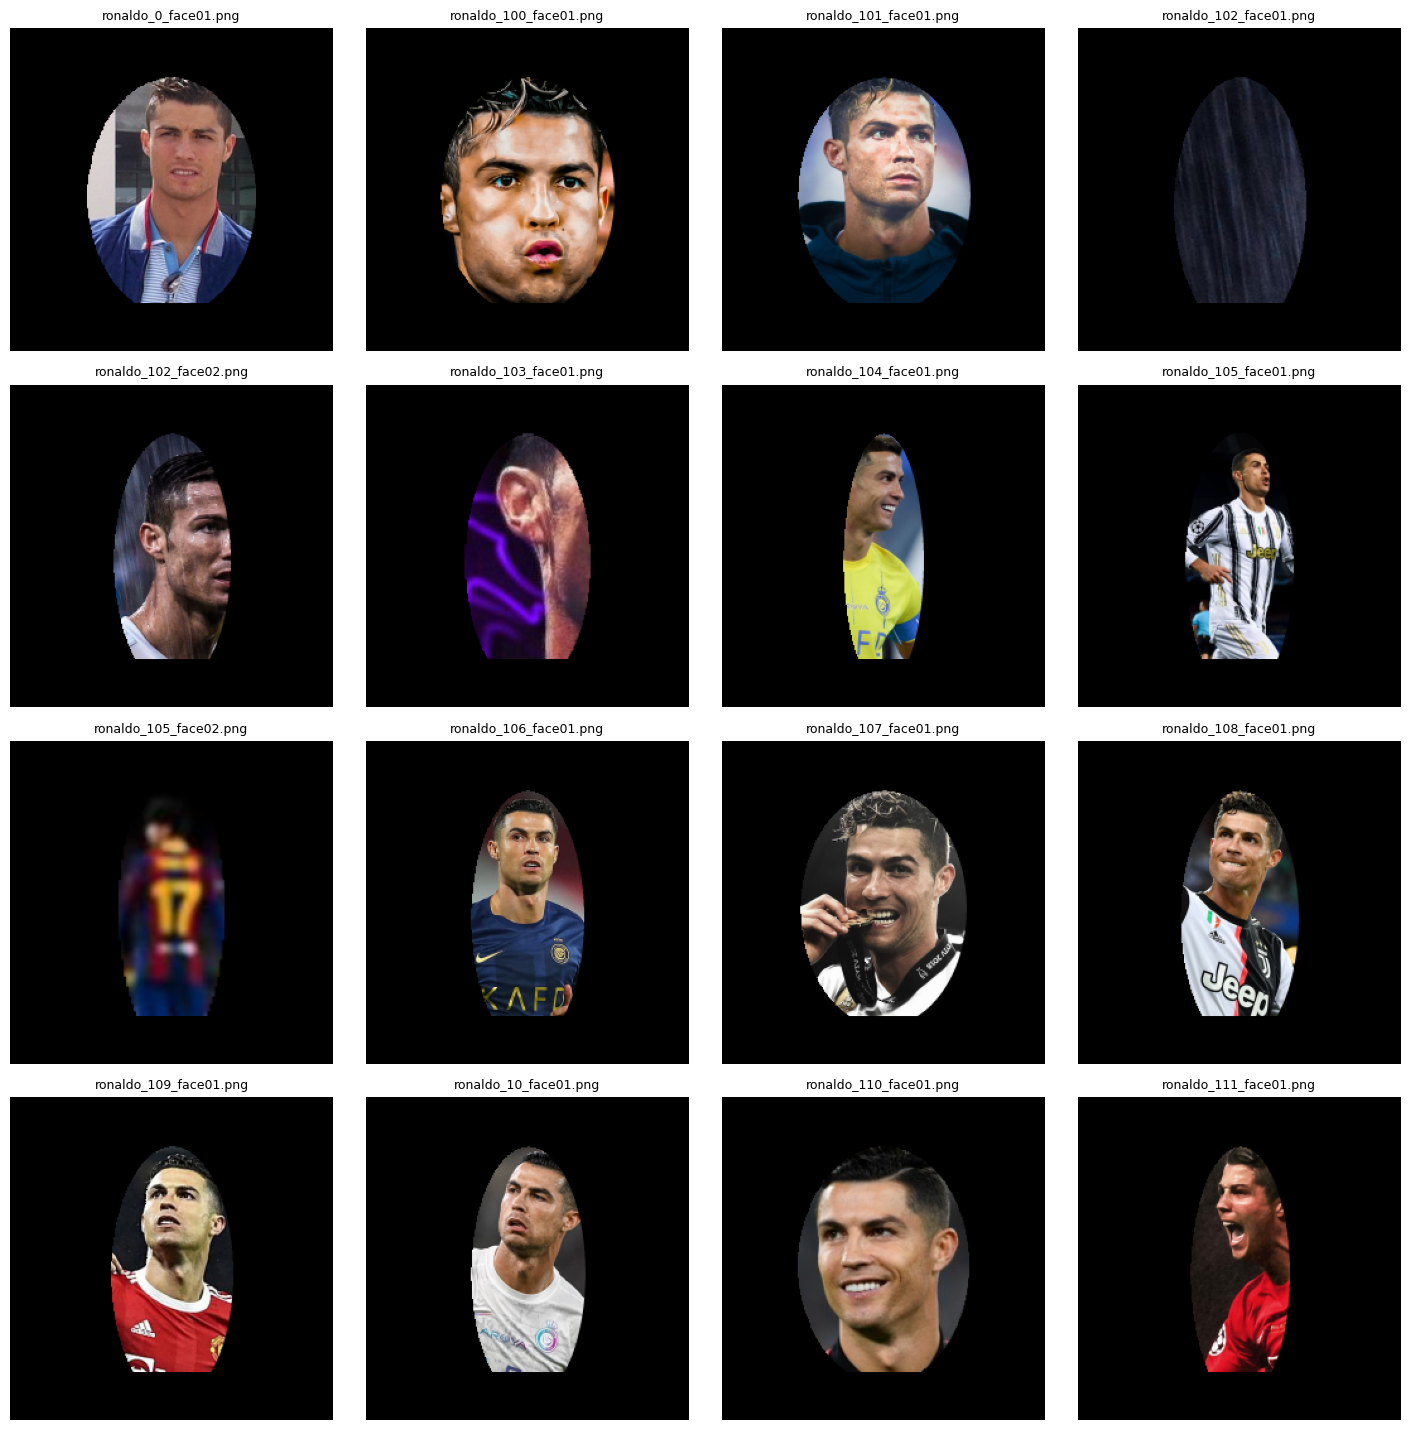

In [ ]:
def verify_export_dimensions(output_dir: Path, expected_size: int = 256) -> Dict[str, Any]:
    checks = {}
    faces_dir = output_dir / "faces"
    if not faces_dir.exists():
        checks["faces"] = {"exists": False, "count": 0, "all_ok": False}
        return checks

    files = sorted([p for p in faces_dir.glob("*.png") if p.is_file()])
    all_ok = True
    for p in files[: min(50, len(files))]:
        with Image.open(p) as img:
            if img.size != (expected_size, expected_size):
                all_ok = False
                break
    checks["faces"] = {"exists": True, "count": len(files), "all_ok": all_ok}
    return checks


def show_samples(output_dir: Path, n: int = 16, cols: int = 4) -> None:
    files = sorted((output_dir / "faces").glob("*.png"))
    if not files:
        print(f"No sample files found in {output_dir / 'faces'}")
        return

    files = files[: min(n, len(files))]
    cols = max(1, int(cols))
    rows = (len(files) + cols - 1) // cols

    plt.figure(figsize=(3.6 * cols, 3.6 * rows))
    for i, p in enumerate(files, start=1):
        img = np.array(Image.open(p).convert("RGB"))
        plt.subplot(rows, cols, i)
        plt.imshow(img)
        plt.title(p.name, fontsize=9)
        plt.axis("off")
    plt.tight_layout()
    plt.show()


# Prefer relaxed Ronaldo outputs if available.
inspect_cfg = ronaldo_cfg_relaxed if "ronaldo_cfg_relaxed" in globals() else example_cfg

dim_report = verify_export_dimensions(inspect_cfg.output_dir, expected_size=inspect_cfg.image_size)
print(f"Inspecting outputs from: {inspect_cfg.output_dir.resolve()}")
print("Dimension report:")
print(json.dumps(dim_report, indent=2))
print("Showing up to 16 extracted samples.")

show_samples(inspect_cfg.output_dir, n=16, cols=4)

## Final Preview: Did face extraction work?
This section renders side-by-side previews for a few samples so you can quickly verify footballer face extraction quality.

Columns shown:
1. Source image (best match by filename stem)
2. Extracted face output

Previewing D:\Users\arthu\Documents\GitHub\CS424GroupProj\outputs_faces_ronaldo_relaxed with up to 10 examples.


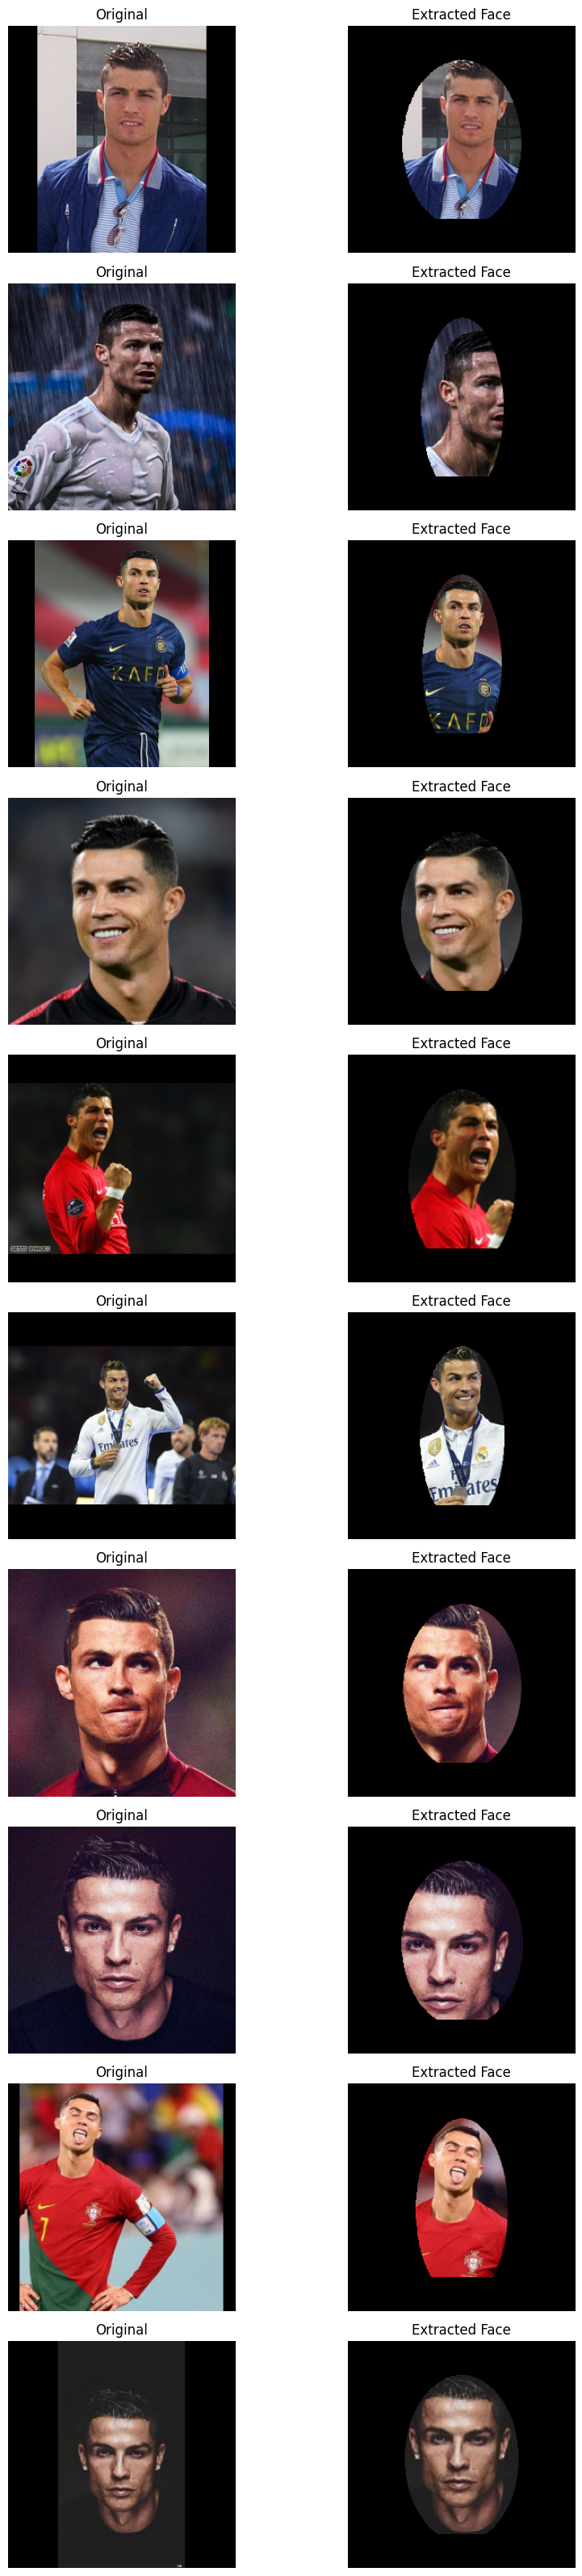

In [ ]:
def _pick_preview_files(face_files: List[Path], n: int) -> List[Path]:
    """Pick files evenly across the dataset to show diverse examples."""
    if not face_files:
        return []
    n = max(1, min(n, len(face_files)))
    if n == len(face_files):
        return face_files

    idxs = np.linspace(0, len(face_files) - 1, n, dtype=int)
    seen = set()
    picked: List[Path] = []
    for i in idxs.tolist():
        if i not in seen:
            seen.add(i)
            picked.append(face_files[i])
    return picked


def preview_face_results(output_dir: Path, dataset_dir: Path, n: int = 10) -> None:
    faces_dir = output_dir / "faces"

    if not faces_dir.exists():
        print(f"No outputs found at {faces_dir}. Run the pipeline cell first.")
        return

    all_face_files = sorted(faces_dir.glob("*.png"))
    if not all_face_files:
        print("No face outputs found. Run the pipeline cell first.")
        return

    face_files = _pick_preview_files(all_face_files, n=n)
    fig, axes = plt.subplots(len(face_files), 2, figsize=(10, 3.2 * len(face_files)))
    if len(face_files) == 1:
        axes = np.expand_dims(axes, axis=0)

    for row, face_path in enumerate(face_files):
        stem = face_path.stem
        if "_face" in stem:
            original_stem = stem.rsplit("_face", 1)[0]
        else:
            original_stem = stem

        original_path = None
        for ext in (".jpg", ".jpeg", ".png", ".bmp", ".webp"):
            candidate = dataset_dir / f"{original_stem}{ext}"
            if candidate.exists():
                original_path = candidate
                break

        if original_path is None:
            matches = list(dataset_dir.rglob(f"{original_stem}.*"))
            original_path = matches[0] if matches else None

        if original_path and original_path.exists():
            original = np.array(Image.open(original_path).convert("RGB"))
            original = resize_with_padding_rgb(original, 256, (0, 0, 0))
        else:
            original = np.zeros((256, 256, 3), dtype=np.uint8)

        extracted_face = np.array(Image.open(face_path).convert("RGB"))

        axes[row, 0].imshow(original)
        axes[row, 0].set_title("Original")
        axes[row, 0].axis("off")

        axes[row, 1].imshow(extracted_face)
        axes[row, 1].set_title("Extracted Face")
        axes[row, 1].axis("off")

        axes[row, 0].set_ylabel(face_path.name, rotation=90, fontsize=9)

    plt.tight_layout()
    plt.show()

# Preview whichever run was used for inspection.
preview_cfg = ronaldo_cfg_relaxed if "ronaldo_cfg_relaxed" in globals() else example_cfg
print(f"Previewing {preview_cfg.output_dir.resolve()} with up to 10 examples.")
preview_face_results(output_dir=preview_cfg.output_dir, dataset_dir=preview_cfg.dataset_dir, n=10)

In [ ]:
# Full Ronaldo run: process every image in the folder.
ronaldo_cfg_all = PipelineConfig(
    dataset_dir=Path("ronaldo"),
    output_dir=Path("outputs_faces_ronaldo_all"),
    max_images=None,
    random_sample=False,
    use_face_feature_verifier=False,
    min_face_component_area=80,
    min_face_bbox_side=20,
    min_face_bbox_area=300,
    min_face_area_ratio=0.00025,
    min_face_fill_ratio=0.05,
    min_face_intensity_std=4.0,
    save_face_mask=False,
    background_color=(0, 0, 0),
)

ronaldo_images = list_images(ronaldo_cfg_all.dataset_dir, ronaldo_cfg_all.supported_exts)
print(f"Found {len(ronaldo_images)} image(s) in {ronaldo_cfg_all.dataset_dir.resolve()}")

summary_all = run_pipeline(ronaldo_cfg_all)
print({k: v for k, v in summary_all.items() if k != "records"})
print("Summary saved to:", (ronaldo_cfg_all.output_dir / "summary.json").resolve())
print("Faces saved in:", (ronaldo_cfg_all.output_dir / "faces").resolve())

Found 286 image(s) in D:\Users\arthu\Documents\GitHub\CS424GroupProj\ronaldo
Processed 50/286 images...
Processed 100/286 images...
Processed 150/286 images...
Processed 200/286 images...


d:\Users\arthu\Documents\GitHub\CS424GroupProj\.venv\Lib\site-packages\PIL\Image.py:1034: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Processed 250/286 images...
Processed 286/286 images...
{'total': 286, 'processed': 286, 'saved_images': 276, 'saved_faces': 299, 'skipped': 10, 'errors': 0, 'skip_reasons': {'no_person': 7, 'no_visible_face': 3}}
Summary saved to: D:\Users\arthu\Documents\GitHub\CS424GroupProj\outputs_faces_ronaldo_all\summary.json
Faces saved in: D:\Users\arthu\Documents\GitHub\CS424GroupProj\outputs_faces_ronaldo_all\faces


In [ ]:
import hashlib

def _safe_export_stem(path_str: str, max_len: int = 90) -> str:
    stem = Path(path_str).stem
    safe = "".join(ch if (ch.isalnum() or ch in ("-", "_")) else "_" for ch in stem).strip("_")
    if not safe:
        safe = "image"
    if len(safe) > max_len:
        digest = hashlib.sha1(stem.encode("utf-8")).hexdigest()[:10]
        safe = f"{safe[:max_len - 11]}_{digest}"
    return safe


def save_outputs(record: Dict[str, Any], out_paths: Dict[str, Path], cfg: PipelineConfig) -> int:
    """Persist extracted face crops to disk and return number of saved faces."""
    stem = _safe_export_stem(record["path"])
    saved_count = 0

    for idx, face_rgb in enumerate(record["face_crops"], start=1):
        if cfg.center_face_exports:
            face_256 = normalize_centered_face_export(
                face_rgb=face_rgb,
                size=cfg.image_size,
                bg=cfg.background_color,
                target_fill_ratio=cfg.target_face_fill_ratio,
                center_y_ratio=cfg.target_face_center_y_ratio,
            )
        else:
            face_256 = resize_with_padding_rgb(face_rgb, cfg.image_size, cfg.background_color)

        Image.fromarray(face_256).save(out_paths["faces"] / f"{stem}_face{idx:02d}.png")
        saved_count += 1

    if cfg.save_face_mask and "face_mask" in out_paths:
        face_mask_256 = resize_with_padding_mask(record["face_mask"], cfg.image_size)
        Image.fromarray(face_mask_256).save(out_paths["face_mask"] / f"{stem}.png")

    return saved_count

In [ ]:
def _crop_passes_quality_gate(
    face_rgb: np.ndarray,
    bg: Tuple[int, int, int] = (0, 0, 0),
    min_fg_area_ratio: float = 0.12,
    min_fg_aspect: float = 0.45,
    max_fg_aspect: float = 1.85,
    min_laplacian_var: float = 26.0,
    min_mean_saturation: float = 18.0,
) -> bool:
    """Reject low-information crops like tiny slivers, heavy blur, or weak color detail."""
    h, w = face_rgb.shape[:2]
    if h <= 0 or w <= 0:
        return False

    bg_arr = np.array(bg, dtype=np.uint8).reshape(1, 1, 3)
    fg = np.any(face_rgb != bg_arr, axis=2)
    fg_count = int(np.count_nonzero(fg))
    total = max(1, h * w)
    if (fg_count / total) < min_fg_area_ratio:
        return False

    ys, xs = np.where(fg)
    if ys.size == 0 or xs.size == 0:
        return False

    y1, y2 = int(ys.min()), int(ys.max())
    x1, x2 = int(xs.min()), int(xs.max())
    bw = max(1, x2 - x1 + 1)
    bh = max(1, y2 - y1 + 1)
    aspect = bw / bh
    if aspect < min_fg_aspect or aspect > max_fg_aspect:
        return False

    roi = face_rgb[y1:y2 + 1, x1:x2 + 1]
    gray = cv2.cvtColor(roi, cv2.COLOR_RGB2GRAY)
    lap_var = float(cv2.Laplacian(gray, cv2.CV_32F).var())
    if lap_var < min_laplacian_var:
        return False

    hsv = cv2.cvtColor(roi, cv2.COLOR_RGB2HSV)
    sat = hsv[:, :, 1]
    sat_fg = sat[fg[y1:y2 + 1, x1:x2 + 1]]
    if sat_fg.size == 0:
        return False
    if float(np.mean(sat_fg)) < min_mean_saturation:
        return False

    return True


# Robustly preserve the true base extractor even if this cell is rerun many times.
if getattr(extract_face_crops, "_is_quality_wrapper", False):
    _extract_face_crops_original = extract_face_crops._original_fn
else:
    _extract_face_crops_original = extract_face_crops

def extract_face_crops(
    rgb: np.ndarray,
    face_mask: np.ndarray,
    min_area: int = 60,
    padding_ratio: float = 0.18,
    bg: Tuple[int, int, int] = (0, 0, 0),
    min_bbox_side: int = 22,
    min_bbox_area: int = 450,
    min_area_ratio: float = 0.00035,
    min_fill_ratio: float = 0.08,
    min_intensity_std: float = 8.0,
    verifier: Optional[FaceFeatureVerifier] = None,
    return_debug: bool = False,
) -> Any:
    """Wrapper over base extractor with an additional quality gate."""
    faces, dropped = _extract_face_crops_original(
        rgb=rgb,
        face_mask=face_mask,
        min_area=min_area,
        padding_ratio=padding_ratio,
        bg=bg,
        min_bbox_side=min_bbox_side,
        min_bbox_area=min_bbox_area,
        min_area_ratio=min_area_ratio,
        min_fill_ratio=min_fill_ratio,
        min_intensity_std=min_intensity_std,
        verifier=verifier,
        return_debug=True,
    )

    dropped = dict(dropped)
    dropped.setdefault("low_quality", 0)

    kept: List[np.ndarray] = []
    for face in faces:
        if _crop_passes_quality_gate(face, bg=bg):
            kept.append(face)
        else:
            dropped["low_quality"] += 1

    if return_debug:
        return kept, dropped
    return kept

# Mark wrapper metadata for safe reapplication.
extract_face_crops._is_quality_wrapper = True
extract_face_crops._original_fn = _extract_face_crops_original

In [ ]:
# Full Ronaldo rerun with stricter filtering enabled.
ronaldo_cfg_filtered = PipelineConfig(
    dataset_dir=Path("ronaldo"),
    output_dir=Path("outputs_faces_ronaldo_filtered"),
    max_images=None,
    random_sample=False,
    center_face_exports=True,
    target_face_fill_ratio=0.92,
    target_face_center_y_ratio=0.5,
    use_face_feature_verifier=True,
    min_verified_face_side=34,
    min_face_landmarks=90,
    min_face_component_area=90,
    min_face_bbox_side=24,
    min_face_bbox_area=420,
    min_face_area_ratio=0.00030,
    min_face_fill_ratio=0.07,
    min_face_intensity_std=5.0,
    save_face_mask=False,
    background_color=(0, 0, 0),
)

ronaldo_images_filtered = list_images(ronaldo_cfg_filtered.dataset_dir, ronaldo_cfg_filtered.supported_exts)
print(f"Found {len(ronaldo_images_filtered)} image(s) in {ronaldo_cfg_filtered.dataset_dir.resolve()}")

summary_filtered = run_pipeline(ronaldo_cfg_filtered)
print({k: v for k, v in summary_filtered.items() if k != "records"})
print("Summary saved to:", (ronaldo_cfg_filtered.output_dir / "summary.json").resolve())
print("Faces saved in:", (ronaldo_cfg_filtered.output_dir / "faces").resolve())

Found 286 image(s) in D:\Users\arthu\Documents\GitHub\CS424GroupProj\ronaldo
Processed 50/286 images...
Processed 100/286 images...
Processed 150/286 images...
Processed 200/286 images...
Processed 250/286 images...
Processed 286/286 images...
{'total': 286, 'processed': 286, 'saved_images': 167, 'saved_faces': 168, 'skipped': 119, 'errors': 0, 'skip_reasons': {'no_verified_face': 105, 'no_person': 7, 'no_visible_face': 7}}
Summary saved to: D:\Users\arthu\Documents\GitHub\CS424GroupProj\outputs_faces_ronaldo_filtered\summary.json
Faces saved in: D:\Users\arthu\Documents\GitHub\CS424GroupProj\outputs_faces_ronaldo_filtered\faces
